# Introduction

The perpose of this notebook is set up a easy and readable solution. If have time I will try to improve performance. 

This notebook include step by step thought process. It's to help me with my own self.

1. Load and explore data
2. Data visualization
3. Preprocess and clean data
4. Choose the right model
5. Tune and Optimize
6. Deploy the model and submit the result

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e11/sample_submission.csv
/kaggle/input/playground-series-s5e11/train.csv
/kaggle/input/playground-series-s5e11/test.csv


In [2]:
# load essential model
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Configuration
RANDOM_SEED = 42
N_FOLDS = 10
USE_GPU = True
np.random.seed(RANDOM_SEED)

# Load and explore data

In [3]:
train = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
sample_submission = pd.read_csv('/kaggle/input/playground-series-s5e11/sample_submission.csv') 

In [4]:
print("______________Train data______________")
print(train.head())
print("______________Test data______________")
print(test.head())
print(sample_submission.head())

______________Train data______________
   id  annual_income  debt_to_income_ratio  credit_score  loan_amount  \
0   0       29367.99                 0.084           736      2528.42   
1   1       22108.02                 0.166           636      4593.10   
2   2       49566.20                 0.097           694     17005.15   
3   3       46858.25                 0.065           533      4682.48   
4   4       25496.70                 0.053           665     12184.43   

   interest_rate  gender marital_status education_level employment_status  \
0          13.67  Female         Single     High School     Self-employed   
1          12.92    Male        Married        Master's          Employed   
2           9.76    Male         Single     High School          Employed   
3          16.10  Female         Single     High School          Employed   
4          10.21    Male        Married     High School          Employed   

         loan_purpose grade_subgrade  loan_paid_back  
0   

In [5]:
# basic statistics
print(train.describe())

                  id  annual_income  debt_to_income_ratio   credit_score  \
count  593994.000000  593994.000000         593994.000000  593994.000000   
mean   296996.500000   48212.202976              0.120696     680.916009   
std    171471.442235   26711.942078              0.068573      55.424956   
min         0.000000    6002.430000              0.011000     395.000000   
25%    148498.250000   27934.400000              0.072000     646.000000   
50%    296996.500000   46557.680000              0.096000     682.000000   
75%    445494.750000   60981.320000              0.156000     719.000000   
max    593993.000000  393381.740000              0.627000     849.000000   

         loan_amount  interest_rate  loan_paid_back  
count  593994.000000  593994.000000   593994.000000  
mean    15020.297629      12.356345        0.798820  
std      6926.530568       2.008959        0.400883  
min       500.090000       3.200000        0.000000  
25%     10279.620000      10.990000        1.

**From the describe above you can tell that loan_paid_back have unbalance data in it. It might cause the bias of prediction of model.**

**It's always a good habbit to check that if there is any nan data in any column.**

In [6]:
train.isnull().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

# Data Visualization

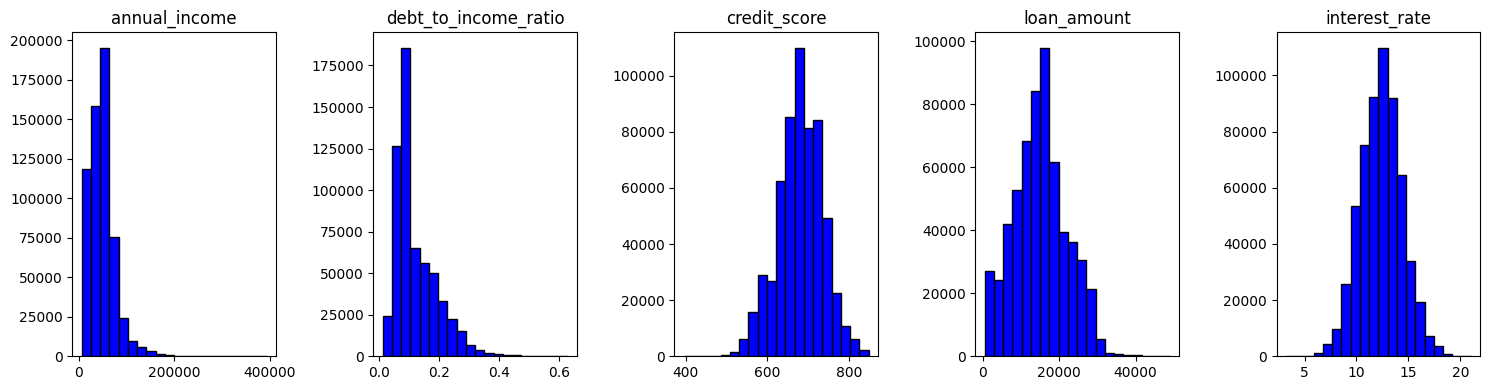

In [7]:
# Create subplots for numeric data 
# annual_income, debt_to_income_ratio, credit_score, loan_amount, interest_rate
fig, axs = plt.subplots(1, 5, figsize=(15, 4))  # 1 row, 5 columns

axs[0].hist(train['annual_income'], bins=20, color='blue', edgecolor='black')
axs[0].set_title('annual_income')

axs[1].hist(train['debt_to_income_ratio'], bins=20, color='blue', edgecolor='black')
axs[1].set_title('debt_to_income_ratio')

axs[2].hist(train['credit_score'], bins=20, color='blue', edgecolor='black')
axs[2].set_title('credit_score')

axs[3].hist(train['loan_amount'], bins=20, color='blue', edgecolor='black')
axs[3].set_title('loan_amount')

axs[4].hist(train['interest_rate'], bins=20, color='blue', edgecolor='black')
axs[4].set_title('interest_rate')
#accident_risk, num_reported_accidents
plt.tight_layout()
plt.show()

You can tell that from distribution of data. There are not a lot of abnormal data in it or maybe we can't tell from this image.

**So this part still need to have further inspect into it.**

# Encode the data

For the data that need to be transform into number. 

So the model can process it.

And you can also visualize it for further analyze

In [8]:
#gender marital_status education_level employment_status loan_purpose grade_subgrade
#the feature above need to be encoded 
# we use "Label Encodeing" because its simple to set up

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
gender_encoded = encoder.fit_transform(train["gender"])
marital_status_encoded = encoder.fit_transform(train["marital_status"])
education_level_encoded = encoder.fit_transform(train["education_level"])
employment_status_encoded = encoder.fit_transform(train["employment_status"])
loan_purpose_encoded = encoder.fit_transform(train["loan_purpose"])
grade_subgrade_encoded = encoder.fit_transform(train["grade_subgrade"])

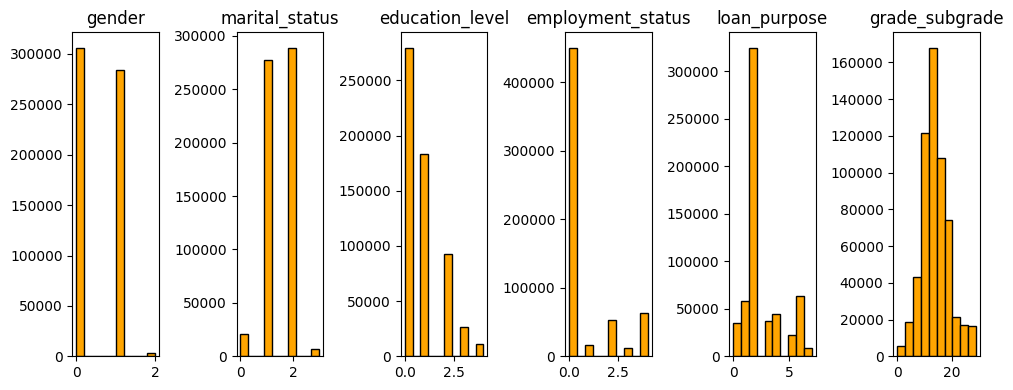

In [9]:
# Create subplots
fig, axs = plt.subplots(1, 6, figsize=(10, 4))  # 1 row, 4 columns
axs[0].hist(gender_encoded, color='orange', edgecolor='black')
axs[0].set_title('gender')
axs[1].hist(marital_status_encoded, color='orange', edgecolor='black')
axs[1].set_title('marital_status')
axs[2].hist(education_level_encoded, color='orange', edgecolor='black')
axs[2].set_title('education_level')
axs[3].hist(employment_status_encoded,color='orange', edgecolor='black')
axs[3].set_title('employment_status')
axs[4].hist(loan_purpose_encoded, color='orange', edgecolor='black')
axs[4].set_title('loan_purpose')
axs[5].hist(grade_subgrade_encoded, color='orange', edgecolor='black')
axs[5].set_title('grade_subgrade')
#accident_risk, num_reported_accidents
plt.tight_layout()
plt.show()

**From the plot above, you can tell that each category all have dominent group in it.**

**We might need to handle it in case the model will have a bias result.**

# Preprocess and clean data

In [10]:
from sklearn.preprocessing import PolynomialFeatures
def preprocess_dataframe(df: pd.DataFrame, drop_cols: list = None) -> pd.DataFrame:
    df = df.copy()

    # Handle missing values
    # Althought there are no missing data there might have missing data in future input data
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
    # Step 0: Drop specified columns 
    
    if drop_cols:
        df = df.drop(columns=drop_cols, errors='ignore')  # 'ignore' avoids errors if column not found

    # Step 1: Encode boolean columns
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    # Step 2: Label encode categorical columns
    label_encoders = {}
    for col in df.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le
    # Step 3: relate feature 
    df['income_loan_ratio'] = df['annual_income'] / (df['loan_amount'] + 1e-6)
    df['loan_to_income'] = df['loan_amount'] / (df['annual_income'] + 1e-6)
    df['total_debt'] = df['debt_to_income_ratio'] * df['annual_income']
    df['available_income'] = df['annual_income'] * (1 - df['debt_to_income_ratio'])
    
    return df

In [11]:
preprocess_train = preprocess_dataframe(train,drop_cols=['loan_paid_back','id'])

In [12]:
preprocess_train.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,income_loan_ratio,loan_to_income,total_debt,available_income
0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,12,11.615155,0.086094,2466.91116,26901.07884
1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,17,4.813311,0.207757,3669.93132,18438.08868
2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,14,2.914776,0.343080,4807.92140,44758.27860
3,46858.25,0.065,533,4682.48,16.10,0,2,1,0,2,25,10.007144,0.099929,3045.78625,43812.46375
4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,15,2.092564,0.477883,1351.32510,24145.37490


# Train model


I need to add test data score into the return data to find out if it is overfitting

Now we need to chose model for the question. 

Here are some tips when it comes to these three model. Here I will use XGBoost for first version.

Use LightGBM when:

* You have large datasets or high-dimensional features.
* You want fast training and low memory usage.

Use XGBoost when:

* You need a well-tested, flexible model with strong performance.
* You’re doing hyperparameter tuning or competing in ML challenges.

Use CatBoost when:

* Your data has many categorical features.
* You want strong default performance with minimal preprocessing.

In [13]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import xgboost as xgb
import optuna

In [14]:
#1. preprocess data for model
train_data = preprocess_dataframe(train,drop_cols=['id'])
test_ids = test['id']
test_data = preprocess_dataframe(test,drop_cols=['id'])

train_x = train_data.drop(['loan_paid_back'] , axis=1)
train_y = train_data['loan_paid_back']

# Hyper parameter with OPTUNA

In [15]:
# 1. 切分訓練集與測試集
X_train, X_test, y_train, y_test = train_test_split(
    train_x, train_y, test_size=0.3, random_state=RANDOM_SEED
)

# 2. 定義目標函數
def objective(trial):
    # 定義要搜尋的超參數範圍
    param = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "use_label_encoder": False,
        "random_state": RANDOM_SEED,
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 1),
    }

    # 建立模型
    model = xgb.XGBClassifier(**param)
    model.fit(X_train, y_train)

    # 預測並計算 AUC
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_prob)
    return auc

# 3. 建立並執行 Optuna study
study = optuna.create_study(direction="maximize")  # 最大化 AUC
study.optimize(objective, n_trials=50)  # 跑 50 次試驗

# 4. 最佳結果
print("最佳參數:", study.best_params)
print("最佳 AUC:", study.best_value)



[I 2025-11-29 09:42:26,308] A new study created in memory with name: no-name-cd88cc76-873c-47ad-af99-7e0a3e6273c9
[I 2025-11-29 09:42:36,131] Trial 0 finished with value: 0.9184808102182699 and parameters: {'max_depth': 7, 'learning_rate': 0.16082685964692878, 'n_estimators': 395, 'subsample': 0.6637063409716071, 'colsample_bytree': 0.66422395566815, 'min_child_weight': 3, 'gamma': 0.742331342983486, 'reg_alpha': 0.12609350869132874, 'reg_lambda': 0.9980290500606586}. Best is trial 0 with value: 0.9184808102182699.
[I 2025-11-29 09:42:41,509] Trial 1 finished with value: 0.9204152333237705 and parameters: {'max_depth': 5, 'learning_rate': 0.16008417653093798, 'n_estimators': 484, 'subsample': 0.9084181872762169, 'colsample_bytree': 0.5515063463237966, 'min_child_weight': 10, 'gamma': 4.742011325975467, 'reg_alpha': 0.5436032993457757, 'reg_lambda': 0.807508260894293}. Best is trial 1 with value: 0.9204152333237705.
[I 2025-11-29 09:42:48,352] Trial 2 finished with value: 0.920655219986

最佳參數: {'max_depth': 5, 'learning_rate': 0.10760706486249845, 'n_estimators': 499, 'subsample': 0.9514333561374941, 'colsample_bytree': 0.7067266246331957, 'min_child_weight': 10, 'gamma': 1.124760888666906, 'reg_alpha': 0.6308027477796924, 'reg_lambda': 0.16862508948983976}
最佳 AUC: 0.9219987171606236


# Submission

In [16]:
# 假設 Optuna 找到的最佳參數存在 study.best_params
best_params = study.best_params

# 1. 建立最佳模型
best_model = xgb.XGBClassifier(
    **best_params,
    objective="binary:logistic",
    eval_metric="auc",
    use_label_encoder=False,
    random_state=RANDOM_SEED
)

# 2. 用訓練集重新訓練模型
best_model.fit(X_train, y_train)

# 3. 在測試集上產生預測機率
y_pred_prob = best_model.predict_proba(test_data)[:, 1]

# 4. Submission file prepare

print("Creating submission file")
submission = pd.DataFrame({'loan_paid_back': y_pred_prob}, index=test_ids)
submission.index.name = 'id'

print("Saving submission file")
submission.to_csv('submission.csv', header=True)

print(f"Submission file created: {submission.shape}")
print("First 5 rows of submission:")
print(submission.head())

Creating submission file
Saving submission file
Submission file created: (254569, 1)
First 5 rows of submission:
        loan_paid_back
id                    
593994        0.949462
593995        0.982214
593996        0.456428
593997        0.915839
593998        0.953098
